

# TP FINAL

El presente trabajo final corresponde al curso “Herramientas Básicas para el Análisis de Datos”, cuyo objetivo es aplicar los conocimientos adquiridos durante la cursada.
A lo largo de este trabajo se ponen en práctica distintas herramientas y técnicas orientadas a la limpieza, análisis e interpretación de datos, con el fin de transformar la información en conocimiento útil.



#Planteo del caso y selección de dataset
## La eleccion del Dataset, corresponde a que es un area de mi interes, lo cual facilitara el analisis y comprension de los resultados obtenidos. Trabaje durante 16 años en el sector automotriz.
### **Planteo del caso** Analizar la evolución de los tramites de transferencias de vehículos en el tiempo para identificar tendencias, variaciones y posibles patrones de comportamiento. Existen patrones estacionales?

# Importamos las librerias necesarias para realizar el analisis

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Montaje del Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


#Subir el Dataset para limpiarlo, analizarlo y obtener informacion


In [ ]:
# Subir el archivo
DF = pd.read_csv('/content/drive/MyDrive/estadistica-transferencias-automotores-2000-01-2026-03.csv')
DF.head()

,tipo_vehiculo,anio_transferencia,mes_transferencia,provincia_transferencia,letra_provincia_transferencia,cantidad_transferencias,provincia_id
0,Automotores,2000,1,Buenos Aires,B,39559,6
1,Automotores,2000,1,Catamarca,K,476,10
2,Automotores,2000,1,Chaco,H,1232,22
3,Automotores,2000,1,Chubut,U,1888,26
4,Automotores,2000,1,Ciudad Autónoma de Bs.As.,C,14427,2


# Exploración Inicial

## Reviso la estructura del dataset con info() para validar tipos de datos, detectar valores nulos y entender la calidad de la información antes de analizarla.


In [ ]:
DF.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7560 entries, 0 to 7559
Data columns (total 7 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   tipo_vehiculo                  7560 non-null   object
 1   anio_transferencia             7560 non-null   int64 
 2   mes_transferencia              7560 non-null   int64 
 3   provincia_transferencia        7560 non-null   object
 4   letra_provincia_transferencia  7560 non-null   object
 5   cantidad_transferencias        7560 non-null   int64 
 6   provincia_id                   7560 non-null   int64 
dtypes: int64(4), object(3)
memory usage: 413.6+ KB


In [ ]:
# En este punto obtendremos la cantidad de filas y columnas del DF. Son 7560 filas y 7 columnas.
DF.shape

(7560, 7)

In [ ]:
# Por ultimo para saber los tipos de datos con los que trabajamos
DF.dtypes

,0
tipo_vehiculo,object
anio_transferencia,int64
mes_transferencia,int64
provincia_transferencia,object
letra_provincia_transferencia,object
cantidad_transferencias,int64
provincia_id,int64


### FUNCIONES SIMPLES

## Aplico describe() para obtener una primera visión estadística , identificar promedios, valores extremos, media, ect.

In [ ]:
DF.describe()
# Todas las columnas tienen la misma cantidad de datos (756000). Primer conclusion importante, la diferencia entre el promedio (50%) y la mediana (mean)
# En este caso el promedio es menor que la mediana, lo que indica que seguramente hay periodos de ventas bajas, seguramente asociados a decisiones macroeconomicas cono un TC fluctuante

,anio_transferencia,mes_transferencia,cantidad_transferencias,provincia_id
count,7560.000000,7560.000000,7560.000000,7560.000000
mean,2012.628571,6.457143,4998.658862,48.000000
std,7.578989,3.464409,9771.602760,27.690578
min,2000.000000,1.000000,51.000000,2.000000
25%,2006.000000,3.000000,809.000000,25.000000
50%,2013.000000,6.000000,1725.500000,48.000000
75%,2019.000000,9.000000,3311.000000,71.000000
max,2026.000000,12.000000,68577.000000,94.000000


##Vericar ausencia de valores nulos con isna() y la inexistencia de duplicados con duplicated(), asegurando consistencia antes del análisis.”

In [ ]:
# Faltantes en cada columna
DF.isna()

,tipo_vehiculo,anio_transferencia,mes_transferencia,provincia_transferencia,letra_provincia_transferencia,cantidad_transferencias,provincia_id
0,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...
7555,False,False,False,False,False,False,False
7556,False,False,False,False,False,False,False
7557,False,False,False,False,False,False,False
7558,False,False,False,False,False,False,False


In [ ]:
DF.duplicated()
# No hay columnas duplicadas

,0
0,False
1,False
2,False
3,False
4,False
...,...
7555,False
7556,False
7557,False
7558,False


#Primeros analisis

In [ ]:
DF.columns

Index(['tipo_vehiculo', 'anio_transferencia', 'mes_transferencia',
       'provincia_transferencia', 'letra_provincia_transferencia',
       'cantidad_transferencias', 'provincia_id'],
      dtype='object')

# Top 10 ( Provincias )


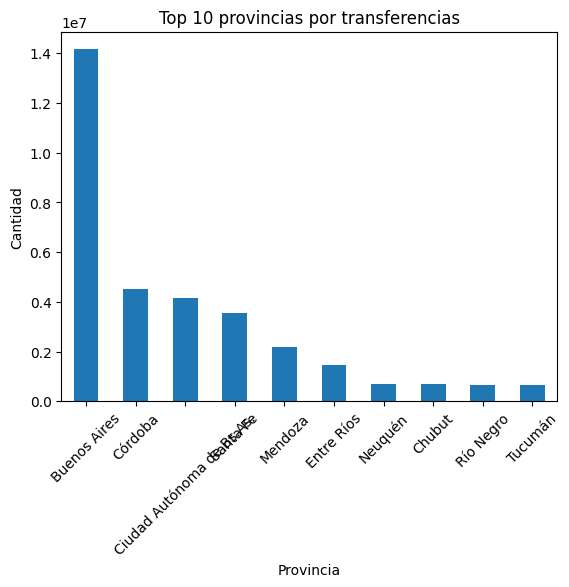

In [ ]:
top_provincias = DF.groupby('provincia_transferencia')['cantidad_transferencias'].sum().sort_values(ascending=False).head(10)

plt.figure()
top_provincias.plot(kind='bar')
plt.title('Top 10 provincias por transferencias')
plt.xlabel('Provincia')
plt.ylabel('Cantidad')
plt.xticks(rotation=45)
plt.show()

# La provincia de Buenos Aires lidera el Top 10. Esta informacion no es casual ya que es la provincia con mayor densidad demografica
# y concentra la mayor parte de la actividad economica.

# Ranking ( años)

In [ ]:
# Rankig

DF_anual = DF.groupby('anio_transferencia')['cantidad_transferencias'].sum().reset_index()
DF_anual

,anio_transferencia,cantidad_transferencias
0,2000,788669
1,2001,624721
2,2002,610154
3,2003,805322
4,2004,928877
5,2005,1034312
6,2006,1224188
7,2007,1370173
8,2008,1409486
9,2009,1328218


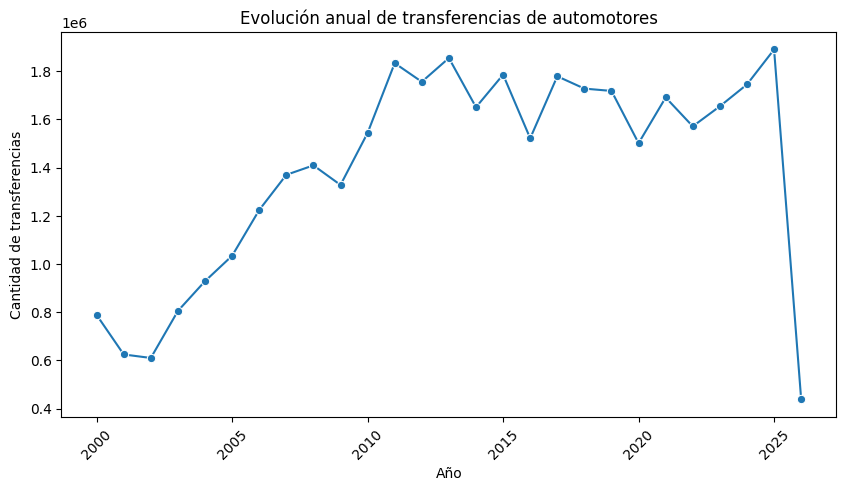

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=DF_anual,
    x='anio_transferencia',
    y='cantidad_transferencias',
    marker='o'
)

plt.title('Evolución anual de transferencias de automotores')
plt.xlabel('Año')
plt.ylabel('Cantidad de transferencias')
plt.xticks(rotation=45)

plt.show()

# En el año 2021 Argentina experimento una gran crisis, la cual obviamente se vio reflejada en el rubro con una caida en las transferencias y petenteamientos.
# La estabilidad del TC hace que en los ultimos años la cantidad de tranferencias y patentamientos tiendan a la suba, conjuntamente con la baja de impuestos al rubro.

# Analisis para observar el comportamiento en el ultimo año y analizar cómo varían las transferencias mes a mes.

In [ ]:
DF_2025 = DF[DF['anio_transferencia'] == 2025]

# Filtro 2025

In [ ]:
DF_2025_mensual = DF_2025.groupby('mes_transferencia')['cantidad_transferencias'].sum().reset_index()
DF_2025_mensual

,mes_transferencia,cantidad_transferencias
0,1,170088
1,2,149547
2,3,143121
3,4,159208
4,5,155014
5,6,143669
6,7,179489
7,8,167702
8,9,171679
9,10,166612


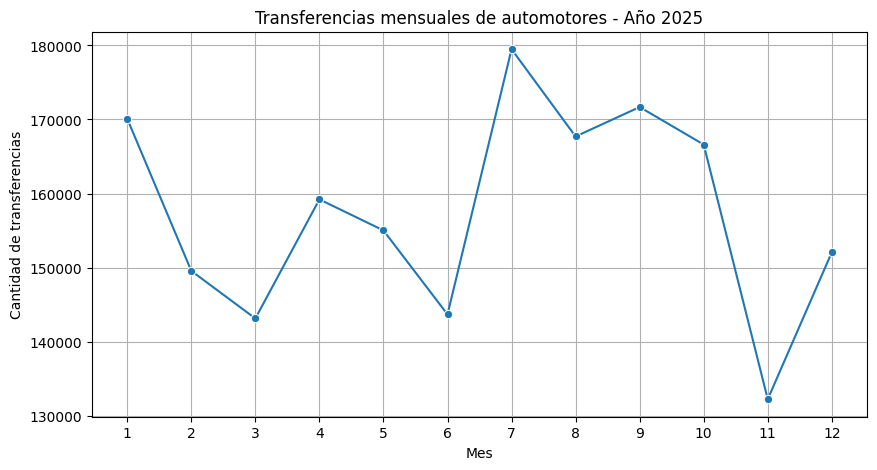

In [ ]:

#El análisis mensual del año 2025 evidencia que las transferencias de automotores no se distribuyen de manera uniforme.
# Existen patrones estecionales ( periodo de vacaciones )y patrones economicos por ejemplo el cobro del SAC, en julio se que aumenta el numero de operaciones.


plt.figure(figsize=(10,5))

sns.lineplot(
    data=DF_2025_mensual,
    x='mes_transferencia',
    y='cantidad_transferencias',
    marker='o'
)

plt.title('Transferencias mensuales de automotores - Año 2025')
plt.xlabel('Mes')
plt.ylabel('Cantidad de transferencias')

plt.xticks(range(1,13))
plt.grid(True)

plt.show()

# Año vs Mes

## Tendencia en el tiempo (vertical)
## Estacionalidad (horizontal)
## Un año muy claro completo → caída general


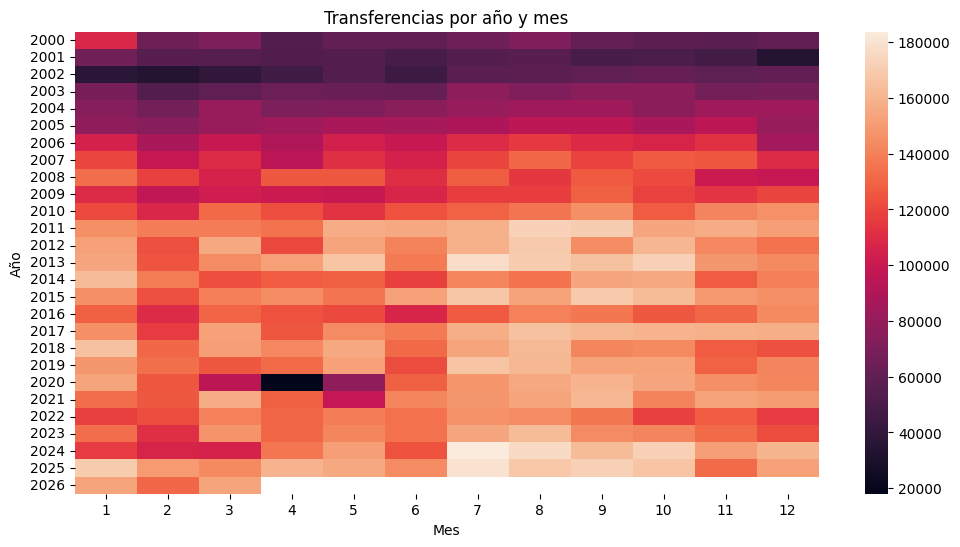

In [ ]:
tabla = DF.groupby(['anio_transferencia', 'mes_transferencia'])['cantidad_transferencias'].sum().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(tabla, annot=False)

plt.title('Transferencias por año y mes')
plt.xlabel('Mes')
plt.ylabel('Año')

plt.show()

# 📊Conclusión final del análisis

## El análisis evidenció que las transferencias de automotores presentan variaciones a lo largo del tiempo, con tendencias, estacionalidad y períodos atípicos. Asimismo, se identificó una concentración por región, lo que refleja un mercado dinámico e influenciado por factores externos.